In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq, ifft

In [12]:
df = pd.read_csv('web_traffic.csv')

In [13]:
# Đọc dữ liệu
df = pd.read_csv('web_traffic.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])


In [14]:
# Trích xuất dữ liệu và loại bỏ thành phần DC
y = df['TrafficCount'].values
y_mean = np.mean(y)
y_detrended = y - y_mean

In [15]:
N = len(y_detrended)
T = 1800  # Khoảng cách mẫu: 30 phút = 1800 giây

# Biến đổi Fourier
yf = fft(y_detrended)
xf = fftfreq(N, T)[:N//2]  # Tần số dương

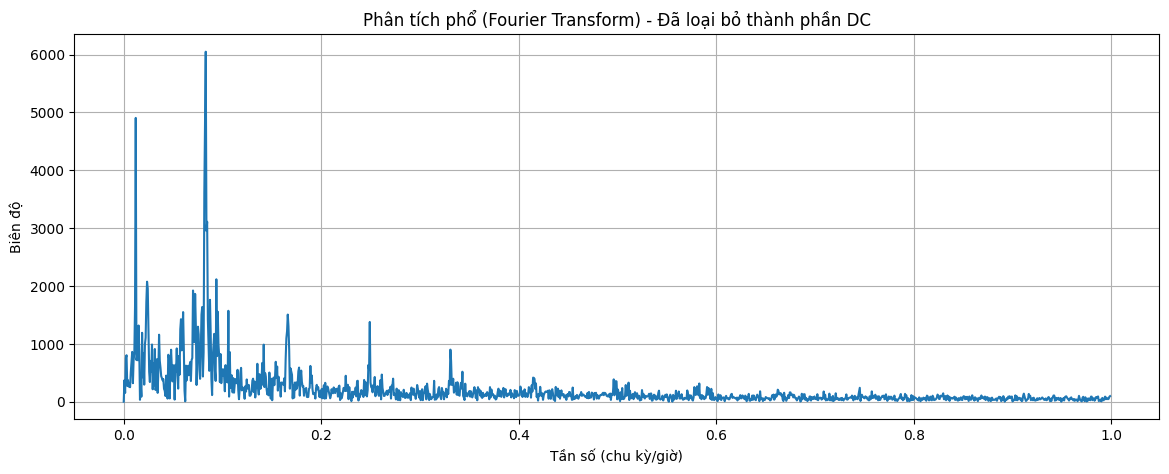

In [16]:
# Vẽ phổ tần số
plt.figure(figsize=(14, 5))
plt.plot(xf / (1/(3600)), 2.0/N * np.abs(yf[:N//2]))
plt.title("Phân tích phổ (Fourier Transform) - Đã loại bỏ thành phần DC")
plt.xlabel("Tần số (chu kỳ/giờ)")
plt.ylabel("Biên độ")
plt.grid(True)
plt.show()


In [17]:
# Giữ lại một số thành phần tần số chính
num_components = 10
indices = np.argsort(np.abs(yf[:N//2]))[::-1][:num_components]

In [18]:
# Lọc phổ
filtered_yf = np.zeros_like(yf, dtype=complex)
for idx in indices:
    filtered_yf[idx] = yf[idx]
    if idx != 0:
        filtered_yf[-idx] = np.conj(yf[idx])  # đối xứng Hermitian

# Biến đổi ngược và cộng lại giá trị trung bình
y_filtered = ifft(filtered_yf).real + y_mean
df['FilteredForecast'] = y_filtered

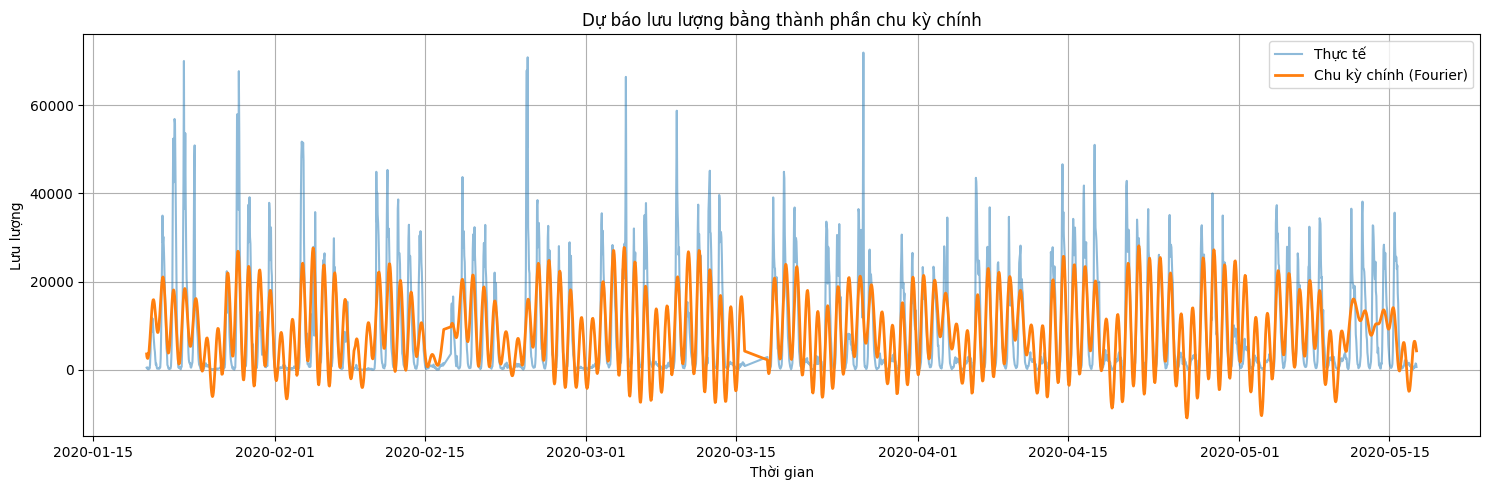

In [19]:
# Vẽ so sánh tín hiệu gốc và dự báo
plt.figure(figsize=(15, 5))
plt.plot(df['Timestamp'], df['TrafficCount'], label='Thực tế', alpha=0.5)
plt.plot(df['Timestamp'], df['FilteredForecast'], label='Chu kỳ chính (Fourier)', linewidth=2)
plt.title("Dự báo lưu lượng bằng thành phần chu kỳ chính")
plt.xlabel("Thời gian")
plt.ylabel("Lưu lượng")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
df

,Timestamp,TrafficCount,FilteredForecast
0,2020-01-20 00:00:00,487.0,3592.460844
1,2020-01-20 00:30:00,385.0,3015.857104
2,2020-01-20 01:30:00,269.0,2653.954273
3,2020-01-20 02:30:00,517.0,2576.517906
4,2020-01-20 03:30:00,129.0,2829.805817
...,...,...,...
2788,2020-05-17 08:30:00,521.0,6470.205486
2789,2020-05-17 09:30:00,1003.0,6202.745557
2790,2020-05-17 10:30:00,1442.0,5697.165046
2791,2020-05-17 11:30:00,1334.0,5031.076356


In [21]:
# Phân tích theo giờ và ngày
df['Hour'] = df['Timestamp'].dt.hour
df['Weekday'] = df['Timestamp'].dt.day_name()

# Trung bình theo giờ
avg_by_hour = df.groupby('Hour')['TrafficCount'].mean()

# Trung bình theo giờ và ngày
avg_by_hour_weekday = df.groupby(['Weekday', 'Hour'])['TrafficCount'].mean().unstack()
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_by_hour_weekday = avg_by_hour_weekday.loc[ordered_days]


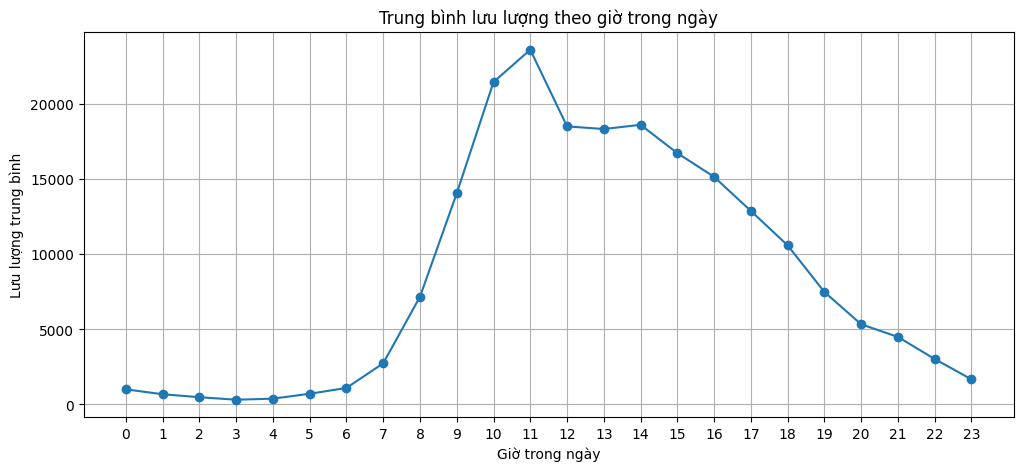

In [22]:
# Vẽ trung bình theo giờ
plt.figure(figsize=(12, 5))
plt.plot(avg_by_hour.index, avg_by_hour.values, marker='o')
plt.title("Trung bình lưu lượng theo giờ trong ngày")
plt.xlabel("Giờ trong ngày")
plt.ylabel("Lưu lượng trung bình")
plt.grid(True)
plt.xticks(range(0, 24))
plt.show()



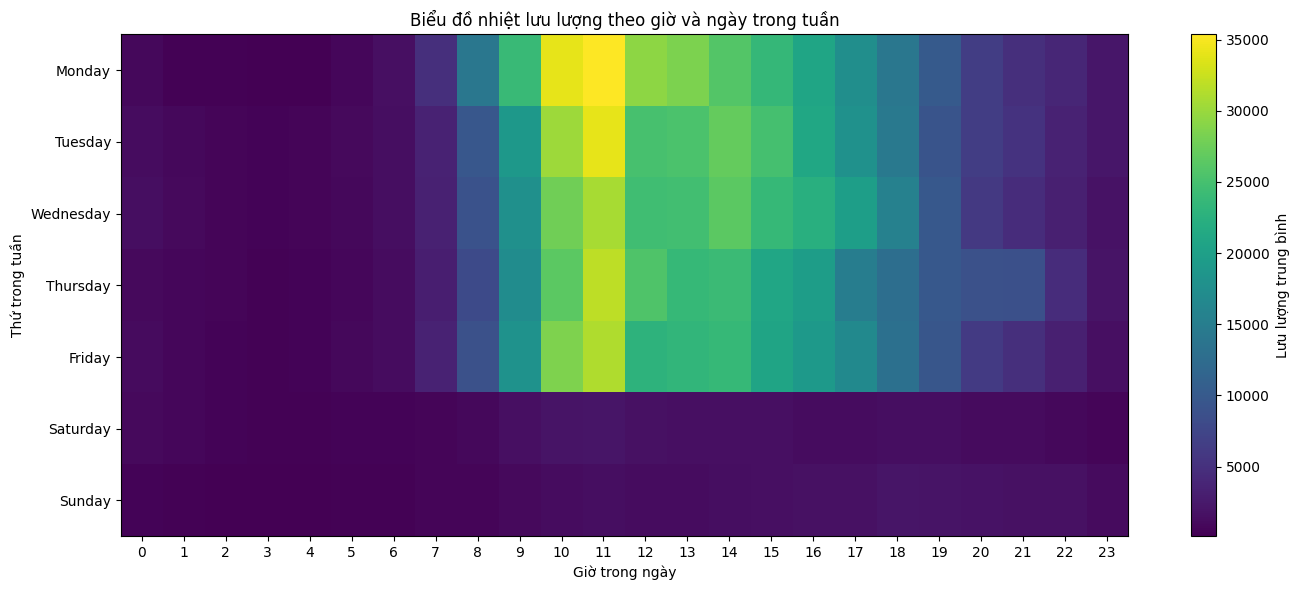

In [23]:
# Vẽ biểu đồ nhiệt
plt.figure(figsize=(14, 6))
plt.imshow(avg_by_hour_weekday, aspect='auto', cmap='viridis')
plt.title("Biểu đồ nhiệt lưu lượng theo giờ và ngày trong tuần")
plt.xlabel("Giờ trong ngày")
plt.ylabel("Thứ trong tuần")
plt.xticks(ticks=np.arange(0, 24), labels=np.arange(0, 24))
plt.yticks(ticks=np.arange(7), labels=ordered_days)
plt.colorbar(label='Lưu lượng trung bình')
plt.tight_layout()
plt.show()